# This is a script for model training a BERT model to recommend songs🎧🎵
-------------------------------------------------------------------------
## In this script we have used a pretrained BERT Large model and trained it on a local GPU using Cuda and Pytorch to accelerate the training process of our mode.



### Cell One:
   In the first cell we imported all the library and the packages then we check if we are working in the correct direct as of our data, then we list all the files 📁 to check if we have our dataset 📄 in there.


### Cell Two:
  In the cell we have loaded the dataset file 📁: " top_10000_1960-now.csv " have then we have extracted the required columns and cleaned the data, next the important part we have called the encoder to encode the string data to vector form, and then we have printed the number of classes, and then we have also listed a sample of the Label_encoder with its vector values of the data.


### Cell Three:
  In this cell we split the data in to training and validation set. Next we check for any error like the rage of labels is not more that the classes and also check for negative value for encoder label which is caused because of missing data, after all this check we print a statement saying all check passed.

### Cell Four:
  In this cell we start with initializing the Hugging face tokenizer for BERT Large_uncased Model. Then we crate a class GenreDataset with argument Dataset object so that PyTorch can load training and validation data in batches for effective computing on GPU.The __init__ function initializes the dataset, __len__ method returns the total number of samples in the dataset 📄. This is required by PyTorch internally.__getitem__ method retrieves one item from the dataset by index idx. Like in the last cell we check the label we again check it because as we are working with cuda which always need a data that s clean at all times because it prevents training on corrupt or wrongly encoded data. This is a typical difficultly/ problem which we face when using cuda. After this we tokenize the data, return a dictionary of tensor then we create dataset objects or both training and validation using GenreDataset class and create dataloader 📄. To confirm the output of the cell we print a statement.

### Cell Five:
  In this cell we made a class BertGenreClassifier which inherits the properties of base class of PyTorch for Neural Network. Then we define a class __init__ and a constructor to check if the class BertGenreClassifier is set up correctly in PyTorch. Further we load a bert-large-uncased model and set parameters like self dropout, then classifier and a forward and Output method for the model. Last we check for gpu and then create a instance for the model on CPU Or GPU then initialize it.

### Cell Six:
  In this cell we define a loss function and then put the model in evaluation mode with one batch of the training data, then print the models output shape and loss.

### Cell Seven:
  In the start of the cell we define a loss function and an optimizer with learning rate of lr+2e-5 and a AMP Automatic Mixed Precision for Past and Easy GPU training of the model. Next we set number of epochs and a training steps with a schedular.

### Cell Eight:
  In this sel we start with setting the early stop parameter then we set the training loop after that we set the validation loop at last we the early stop setup to avoid overfitting problem.

### Cell Nine:
  In this cell we loads the saved model and then swith it evaluation mode then we calculate its overall accuracy and classification using the sklearn.metrics library.


### Cell Ten:

In this cell, we finally make the confusion matrix of the top 50 classes of the ready model and also calculate the f1 curve as there are 502 classes it is difficult to make a f1 graph.

---------------------------------------------------------------------------------------------------------------------
## How to Run the SL Model:
### Step 1 :
  Download the folder named Sl from the drive link shared, then unzip the folder.

### Step 2 :
  Open the file named SL_TEST_SCRIPT.py .

### Step 3 :
  Run the script, after running check the output window.
  There will be to option to enter : quit or next.
  If you enter next it will show you another output.
  if you enter quit it will exit and end the script.

--------------------------------------------------------------------------------------------------------------------------



In [ ]:

## CELL ONE ##

import os
import time
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from transformers import BertTokenizer, BertModel, get_scheduler
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.utils.multiclass import unique_labels
# Debugging: check file structure
print(f"Current working directory: {os.getcwd()}")
print(f"Files in current directory: {os.listdir()}")


## Output for the cell one:
### Current working directory 📁 :
C:\Users\Abhi\PycharmProjects\JupyterProject


### Files 📄 in current directory:
[ ' .idea ', ' Anaconda3 ' , ' bert_genre_classifier.pt ' , 'best_model.pt' , ' data ' , ' label_encoder.pkl ' , ' model.ipynb ' , ' models ' , ' README.md ' , ' requirements.txt ' , ' sample.ipynb ' , ' test_model_2.pt ' , ' validation_predictions.csv ' ]

In [ ]:

## CELL TWO ##

# Load and clean data
df = pd.read_csv('data/top_10000_1960-now.csv')

# Filter rows with missing essential fields
df = df[df['Artist Genres'].notnull() & df['Track Name'].notnull() & df['Artist Name(s)'].notnull() & df['Album Name'].notnull()]

# Create text and label columns
df['text_column'] = df['Track Name'] + ' by ' + df['Artist Name(s)'] + ' from the album ' + df['Album Name']

# Use first genre as label, stripping spaces
df['label_column'] = df['Artist Genres'].str.split(',').str[0].str.strip()

# Encode genre labels to integers
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label_column'])

print(f"Number of classes: {len(label_encoder.classes_)}")
print("Sample data 📄 :")
print(df[['text_column', 'label_column', 'label_encoded']].head())


 ## Output for the cell two:


### Number of classes:
502

### Sample data 📄 :
           No.| text columb                                       | Label_Columb |   label_encoded  |

           1  | Justified & Ancient - Stand by the Jams by The... |  acid house  |        2         |

           2  | I Know You Want Me (Calle Ocho) by Pitbull fro... |  dance pop   |       190        |

           3  | From the Bottom of My Broken Heart by Britney ... |  dance pop   |       190        |

           4  | Apeman - 2014 Remastered Version by The Kinks ... |  album rock  |        17        |

           5  | You Can't Always Get What You Want by The Roll... |  album rock  |        17        |




In [ ]:

## CELL THREE ##

# Split dataset into train and validation sets
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text_column'].tolist(),
    df['label_encoded'].tolist(),
    test_size=0.2,
    random_state=42
)

# Sanity checks for label range
num_classes = len(label_encoder.classes_)

assert max(train_labels) < num_classes, f"Train labels max {max(train_labels)} >= num_classes {num_classes}"
assert max(val_labels) < num_classes, f"Validation labels max {max(val_labels)} >= num_classes {num_classes}"
assert min(train_labels) >= 0, f"Train labels min {min(train_labels)} < 0"
assert min(val_labels) >= 0, f"Validation labels min {min(val_labels)} < 0"

print(" ✅ Label range checks passed.")


## Output for the cell three:

✅ Label range checks passed.


In [ ]:

## CELL FOUR ##

# Loading BERT tokenizer from Hugging face
tokenizer = BertTokenizer.from_pretrained('bert-large-uncased')

# Defining PyTorch Dataset class with label checks
class GenreDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        label = self.labels[idx]
        if label >= num_classes or label < 0:
            raise ValueError(f"Invalid label {label} at index {idx}. Must be between 0 and {num_classes-1}")

        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create Dataset and DataLoader
train_dataset = GenreDataset(train_texts, train_labels, tokenizer)
val_dataset = GenreDataset(val_texts, val_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

print("✅ Datasets and DataLoaders ready.")


## Output for the cell four:
✅ Datasets and DataLoaders ready.

In [ ]:

## CELL FIVE ##

class BertGenreClassifier(nn.Module):
    def __init__(self, num_labels):
        super(BertGenreClassifier, self).__init__()
        self.bert = BertModel.from_pretrained('bert-large-uncased')
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        x = self.dropout(pooled_output)
        return self.classifier(x)

# Setting  up an instance on the device CPU/GPU for training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Instantiate model and move to device
model = BertGenreClassifier(num_classes).to(device)
print("✅ Model initialized.")


## Output for the cell five:

    Using device: cuda

✅ Model initialized.

In [ ]:

## CELL SIX ##

# Redefining the loss function (CrossEntropyLoss for classification)
criterion = nn.CrossEntropyLoss()

# Switch to evaluation mode
model.eval()

# Getting one batch from the train loader
batch = next(iter(train_loader))
input_ids = batch['input_ids'].to(device)
attention_mask = batch['attention_mask'].to(device)
labels = batch['labels'].to(device)

# Forward pass without gradient computation
with torch.no_grad():
    outputs = model(input_ids, attention_mask)
    print("Model output shape:", outputs.shape)  # Expected: [batch_size, num_classes]

    loss = criterion(outputs, labels)
    print("Sample loss:", loss.item())  # Should be a float value

## Output for the cell six:

In [ ]:

## CELL SEVEN ##

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-5)
scaler = torch.amp.GradScaler(device="cuda")

#____________________________________________________________________________________________________________________________________________________________________________________________


epochs = 10
print(f"epochs = {epochs}")


#____________________________________________________________________________________________________________________________________________________________________________________________

# Scheduler setup
num_training_steps = epochs * len(train_loader)
scheduler = get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

print(" ✅ Optimizer, criterion, scheduler set.")


## Output for the cell Seven:

        epochs = 10
 ✅ Optimizer, criterion, scheduler set.

In [ ]:

## CELL EIGHT ##

# Early stopping params
best_accuracy = 0.0
patience = 3
patience_counter = 0

for epoch in range(epochs):
    start_time = time.time()
    model.train()
    # training Setup
    total_loss = 0
    correct_train = 0
    total_train = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type="cuda"):
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()

        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    avg_train_loss = total_loss / len(train_loader)
    train_accuracy = correct_train / total_train
    print(f"Epoch {epoch+1} Training Loss: {avg_train_loss:.4f}")
    print(f"Epoch {epoch+1} Training Accuracy: {train_accuracy:.4f}")

    # Validation setup
    model.eval()
    val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            with torch.amp.autocast(device_type="cuda"):
                outputs = model(input_ids, attention_mask)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = correct_val / total_val
    print(f"Epoch {epoch+1} Validation Loss: {avg_val_loss:.4f}")
    print(f"Epoch {epoch+1} Validation Accuracy: {val_accuracy:.4f}")
    print(f"Epoch {epoch+1} completed in {(time.time() - start_time):.2f} seconds")

    # Early stopping Setup
    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        patience_counter = 0
        torch.save(model.state_dict(), 'test-4')
        print("✅ Best model saved.")
    else:
        patience_counter += 1
        print(f"⏳ No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("⏹️ Early stopping triggered.")
            break



## Output for the cell Eight:

Epoch 1 Training: 100%|██████████| 945/945 [04:09<00:00,  3.78it/s]

Epoch 1 Training Loss: 4.4640

Epoch 1 Training Accuracy: 0.1961

Epoch 1 Validation Loss: 3.6165

Epoch 1 Validation Accuracy: 0.3238

Epoch 1 completed in 259.74 seconds

✅ Best model saved.


----------------------------------------------------------------------------------------------------------------------------


Epoch 2 Training: 100%|██████████| 945/945 [03:50<00:00,  4.10it/s]

Epoch 2 Training Loss: 3.0894

Epoch 2 Training Accuracy: 0.4330

Epoch 2 Validation Loss: 2.6493

Epoch 2 Validation Accuracy: 0.5148

Epoch 2 completed in 244.89 seconds

✅ Best model saved.

.
.
.
.



In [ ]:

## CELL NINE ##

# Load best saved model
model.load_state_dict(torch.load('SL_MODEL.pt'))

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        with torch.amp.autocast(device_type="cuda"):
            outputs = model(input_ids, attention_mask)
            _, preds = torch.max(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate accuracy and print report
accuracy = accuracy_score(all_labels, all_preds)
print(f"\n✅ Final Validation Accuracy: {accuracy:.4f}")

from sklearn.metrics import classification_report

# Determine which labels were actually used
used_labels = sorted(set(all_labels) | set(all_preds))

# Subset of class names for the used labels only
used_target_names = [label_encoder.classes_[i] for i in used_labels]

# Generate classification report using only those classes
print("\n📄 Classification Report:")
print(classification_report(all_labels, all_preds,
                            labels=used_labels,
                            target_names=used_target_names,
                            zero_division=0))




## Output for the cell Nine:

       accuracy = 0.85


In [ ]:
# Compute confusion matrix

label_counts = Counter(all_labels)
top_50_labels = [label for label, _ in label_counts.most_common(50)]


top_50_indices = [np.where(label_encoder.classes_ == label_encoder.classes_[i])[0][0] for i in top_50_labels]


mask = np.isin(all_labels, top_50_labels)
filtered_labels = np.array(all_labels)[mask]
filtered_preds = np.array(all_preds)[mask]


cm = confusion_matrix(filtered_labels, filtered_preds, labels=top_50_labels)
target_names = label_encoder.inverse_transform(top_50_labels)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(22, 20))
sns.set(font_scale=1.3)
sns.heatmap(cm_normalized, annot=False, fmt=".2f",
            xticklabels=target_names, yticklabels=target_names,
            cmap="Blues", square=True)
plt.xlabel("Predicted", fontsize=18)
plt.ylabel("True", fontsize=18)
plt.title("Normalized Confusion Matrix (Top 50 Classes)", fontsize=20)
plt.xticks(rotation=90, fontsize=16)
plt.yticks(rotation=0, fontsize=16)
plt.tight_layout()
plt.show()

results_df = pd.DataFrame({
    "text": val_texts,
    "true_label": label_encoder.inverse_transform(all_labels),
    "predicted_label": label_encoder.inverse_transform(all_preds)
})
results_df.to_csv("validation_predictions_top_50.csv", index=False)
print("📁 Saved prediction results to 'validation_predictions.csv'")

# Compute macro/micro F1
f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
f1_micro = f1_score(all_labels, all_preds, average='micro', zero_division=0)
precision_macro = precision_score(all_labels, all_preds, average='macro', zero_division=0)
recall_macro = recall_score(all_labels, all_preds, average='macro', zero_division=0)

print(f"📊 Macro F1 Score: {f1_macro:.4f}")
print(f"📊 Micro F1 Score: {f1_micro:.4f}")
print(f"📊 Macro Precision: {precision_macro:.4f}")
print(f"📊 Macro Recall: {recall_macro:.4f}")

## Output for the cell Ten:

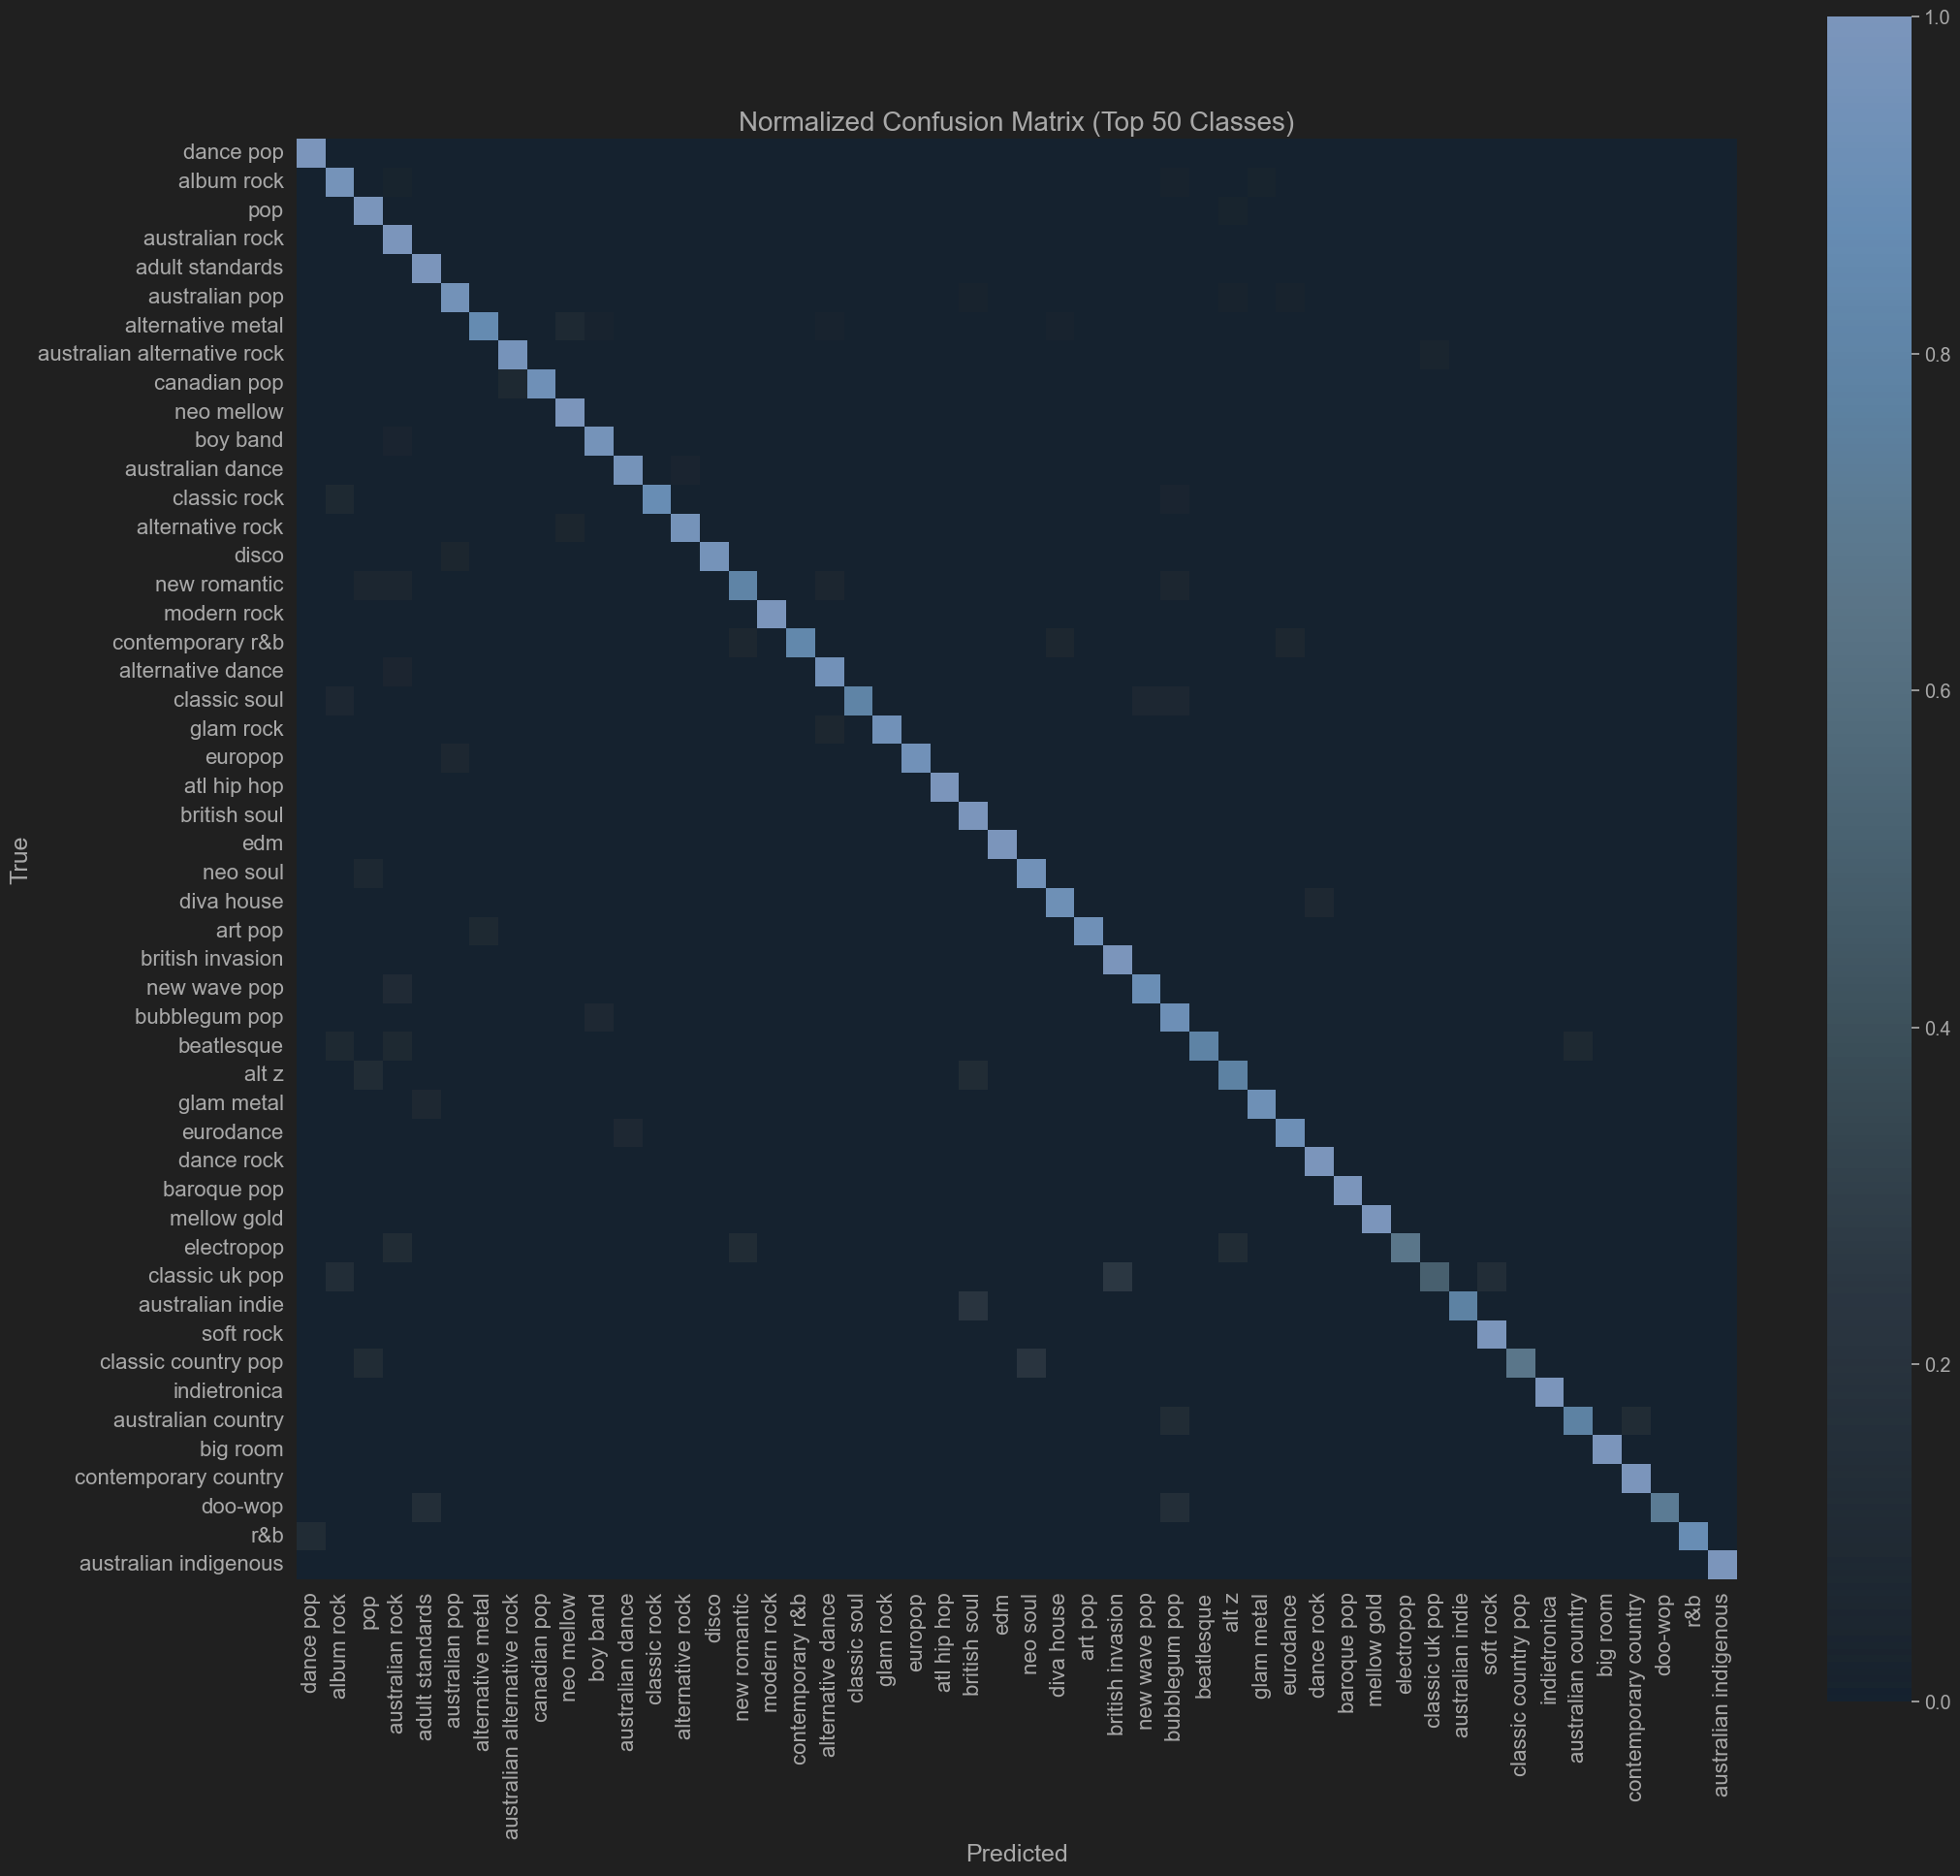

📁 Saved prediction results to 'validation_predictions.csv'

📊 Macro F1 Score: 0.5688

📊 Micro F1 Score: 0.8503

📊 Macro Precision: 0.5771

📊 Macro Recall: 0.5898